In [2]:
import pandas as pd
import glob
import numpy as np
import tqdm
import scipy
import matplotlib.pyplot as plt
import datetime as dt

In [3]:
files = np.sort(glob.glob("/g/data/ng72/ab4502/capacity_factor/hourly_cf_ts_barra_c*"))
file_years = np.array([int(f.split("/")[-1].split("_")[5][0:4]) for f in files])
file_months = np.array([int(f.split("/")[-1].split("_")[5][4:6]) for f in files])

In [8]:
df = pd.DataFrame()
for f in tqdm.tqdm(files[(file_years >= 1979) & (file_years <= 2019)]):

    df = pd.concat([df,pd.read_csv(f)], axis=0)

100%|██████████| 492/492 [00:41<00:00, 11.91it/s] 


In [9]:
df = df.set_index(pd.DatetimeIndex(df["time"]))

In [10]:
df = df.drop(columns="time")

In [11]:
df = df.set_index(df.index + dt.timedelta(hours=10))

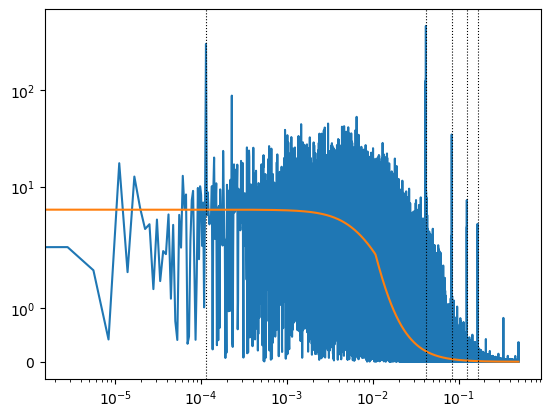

In [13]:
f, p_xx = scipy.signal.periodogram(df["illawara"])

alpha1 = np.corrcoef(df["illawara"].iloc[0:-1],df["illawara"].shift(-1).iloc[0:-1])[1,0]
var_noise = (1 - alpha1**2) * df["illawara"].var()

plt.plot(f, p_xx)
plt.plot(f,var_noise / (1 + alpha1**2 - 2*alpha1*np.cos(2 * np.pi * f)))
plt.yscale("symlog")
plt.xscale("log")

plt.gca().axvline(1/24,ls=':',color="k",lw=0.8)
plt.gca().axvline(1/12,ls=':',color="k",lw=0.8)
plt.gca().axvline(1/8,ls=':',color="k",lw=0.8)
plt.gca().axvline(1/6,ls=':',color="k",lw=0.8)

plt.gca().axvline(1/(24*365),ls=':',color="k",lw=0.8)


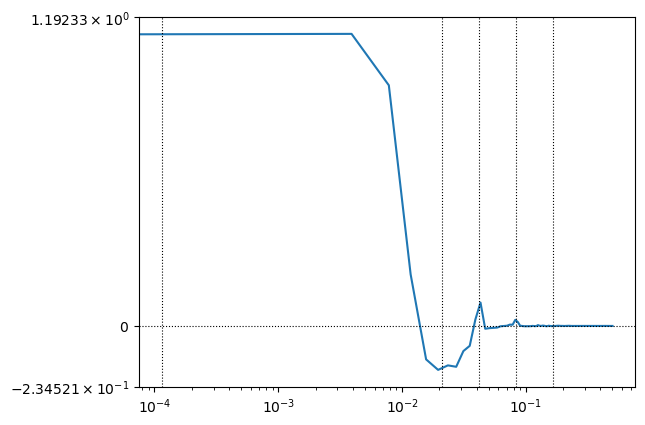

In [14]:
def plot_co_spectrum(x,y):

    f, p_xy = scipy.signal.csd(x,y)
    
    quad = np.imag(p_xy)
    co_spec = np.real(p_xy)
    
    amp = np.abs(p_xy)
    phase = np.angle(p_xy)
    

    plt.plot(f, co_spec)
    
    plt.yscale("symlog")
    plt.xscale("log")
    
    plt.gca().axvline(1/24,ls=':',color="k",lw=0.8)
    plt.gca().axvline(1/12,ls=':',color="k",lw=0.8)
    plt.gca().axvline(1/6,ls=':',color="k",lw=0.8)
    
    plt.gca().axvline(1/(24*2),ls=':',color="k",lw=0.8)
    
    plt.gca().axvline(1/(24*365),ls=':',color="k",lw=0.8)

    plt.gca().axhline(0,ls=':',color="k",lw=0.8)

plot_co_spectrum(df["illawara"],df["southern"])



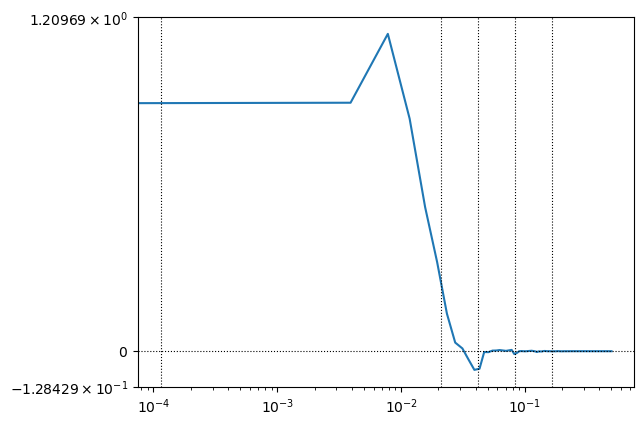

In [15]:
def plot_quad_spectrum(x,y):

    f, p_xy = scipy.signal.csd(x,y)
    
    quad = np.imag(p_xy)
    co_spec = np.real(p_xy)
    
    amp = np.abs(p_xy)
    phase = np.angle(p_xy)
    

    plt.plot(f, quad)
    
    plt.yscale("symlog")
    plt.xscale("log")
    
    plt.gca().axvline(1/24,ls=':',color="k",lw=0.8)
    plt.gca().axvline(1/12,ls=':',color="k",lw=0.8)
    plt.gca().axvline(1/6,ls=':',color="k",lw=0.8)
    
    plt.gca().axvline(1/(24*2),ls=':',color="k",lw=0.8)
    
    plt.gca().axvline(1/(24*365),ls=':',color="k",lw=0.8)

    plt.gca().axhline(0,ls=':',color="k",lw=0.8)

plot_quad_spectrum(df["illawara"],df["southern"])



In [18]:
def read_csv(path):

    df = pd.read_csv(path)
    df["time"] = pd.to_datetime(df["time"])
    return df.set_index("time").loc[slice("1979-01-01","2019-12-31 23:00")]

bunbury = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/bunbury.csv")
gipps = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/gipps.csv")
illawara = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/illawara.csv")
newcastle = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/newcastle.csv")
sa = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/sa.csv")
southern = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/southern.csv")
tas = read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/tas.csv")

In [20]:
df_summer = df[np.in1d(df.index.month,[1,2,12])]

In [42]:
df_illawara = df_summer[np.in1d(df_summer.index.date,illawara[illawara.sb==1].index.date)]
df_not_illawara = df_summer[np.in1d(df_summer.index.date,illawara[illawara.sb==0].index.date)]

df_southern = df_summer[np.in1d(df_summer.index.date,southern[southern.sb==1].index.date)]
df_not_southern = df_summer[np.in1d(df_summer.index.date,southern[southern.sb==0].index.date)]

df_newcastle = df_summer[np.in1d(df_summer.index.date,newcastle[newcastle.sb==1].index.date)]
df_not_newcastle = df_summer[np.in1d(df_summer.index.date,newcastle[newcastle.sb==0].index.date)]

df_sa = df_summer[np.in1d(df_summer.index.date,sa[sa.sb==1].index.date)]
df_not_sa = df_summer[np.in1d(df_summer.index.date,sa[sa.sb==0].index.date)]

df_tas = df_summer[np.in1d(df_summer.index.date,tas[tas.sb==1].index.date)]
df_not_tas = df_summer[np.in1d(df_summer.index.date,tas[tas.sb==0].index.date)]

df_gipps = df_summer[np.in1d(df_summer.index.date,gipps[gipps.sb==1].index.date)]
df_not_gipps = df_summer[np.in1d(df_summer.index.date,gipps[gipps.sb==0].index.date)]

df_bunbury = df_summer[np.in1d(df_summer.index.date,bunbury[bunbury.sb==1].index.date)]
df_not_bunbury = df_summer[np.in1d(df_summer.index.date,bunbury[bunbury.sb==0].index.date)]

In [43]:
names = ["South Australia","Southern","Tasmania","Gippsland","Illawarra","Newcastle","Bunbury Nearshore","Bunbury Offshore"]
df_ratio = pd.DataFrame(columns=names,index=names,dtype=float)

In [44]:
for region_a, an in tqdm.tqdm(zip(["sa","southern","tas","gipps","illawara","newcastle","bunbury_near","bunbury_offshore"],names)):
    for region_b_sb, region_b_no_sb, bn in zip(
        [df_sa,df_southern,df_tas,df_gipps,df_illawara,df_newcastle,df_bunbury],
        [df_not_sa,df_not_southern,df_not_tas,df_not_gipps,df_not_illawara,df_not_newcastle,df_not_bunbury],
        names):

        df_ratio.loc[an,bn] = (region_b_sb[region_a].groupby(region_b_sb.index.hour).mean() / \
                                region_b_no_sb[region_a].groupby(region_b_no_sb.index.hour).mean())[17]

        

8it [00:00, 34.74it/s]


<Axes: >

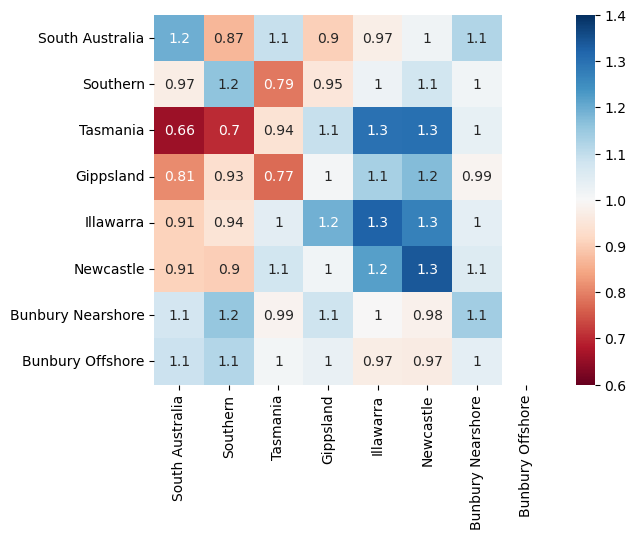

In [45]:
import seaborn as sns
sns.heatmap(
    df_ratio,
    vmin=0.6,
    vmax=1.4,
    cmap="RdBu",
    annot=True)

6it [00:00, 15.74it/s]


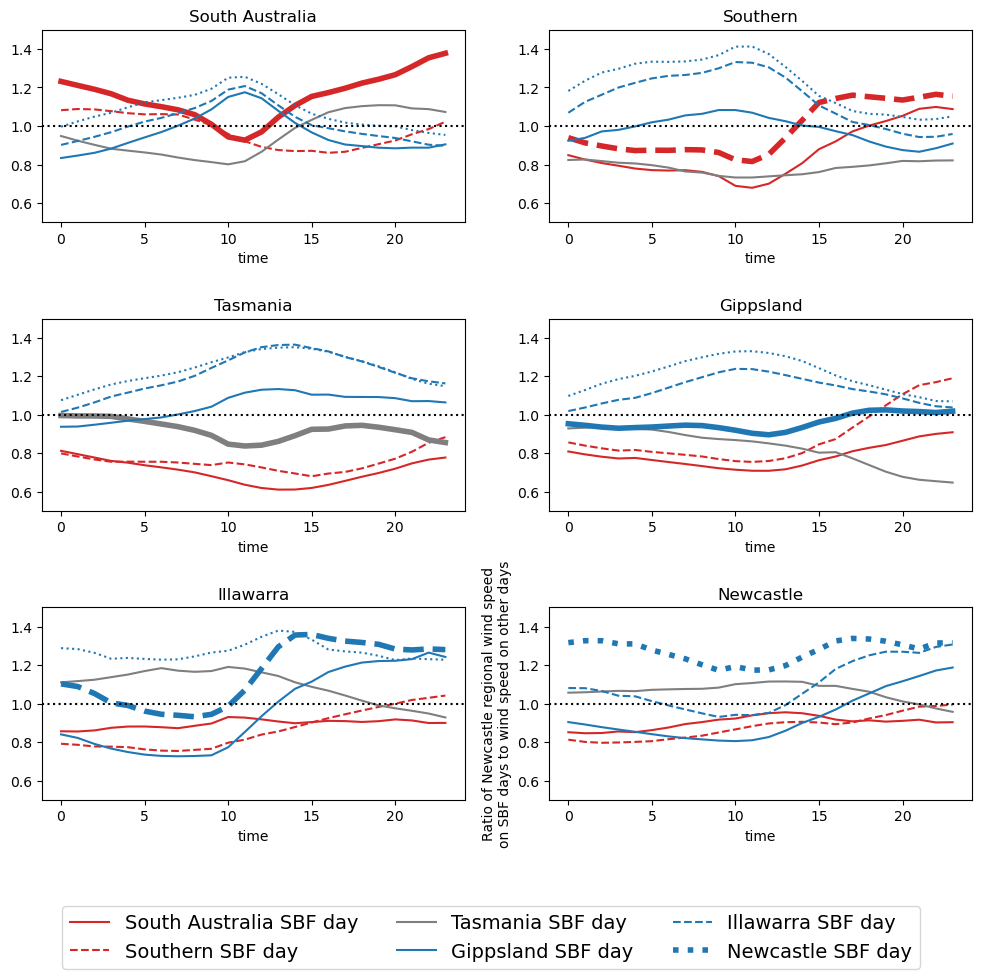

In [49]:
plt.figure(figsize=[12,10])
cnt=1

cols = ["tab:red","tab:red","tab:grey","tab:blue","tab:blue","tab:blue"]
ls = ["-","--","-","-","--",":"]

for region_a, an in tqdm.tqdm(zip(["sa","southern","tas","gipps","illawara","newcastle"],names)):

    plt.subplot(3,2,cnt)
    plt.title(an)
    
    for region_b_sb, region_b_no_sb, bn, c, l in zip(
        [df_sa,df_southern,df_tas,df_gipps,df_illawara,df_newcastle],
        [df_not_sa,df_not_southern,df_not_tas,df_not_gipps,df_not_illawara,df_not_newcastle],
        names,
        cols,
        ls):

        if an==bn:
            lw=4
        else:
            lw=1.5
    
        (region_b_sb[region_a].groupby(region_b_sb.index.hour).mean() /\
             region_b_no_sb[region_a].groupby(region_b_no_sb.index.hour).mean()).plot(label=bn + " SBF day",color=c,ls=l,lw=lw)

    cnt=cnt+1

    plt.gca().axhline(1,ls=":",color="k")
    plt.ylim([0.5,1.5])
    
    

plt.ylabel("Ratio of Newcastle regional wind speed\non SBF days to wind speed on other days")
plt.subplots_adjust(hspace=0.5)

plt.legend(ncol=3,fontsize=14,bbox_to_anchor=(0.9,-0.5))

In [35]:
df_bunbury = df_summer[np.in1d(df_summer.index.date,bunbury[bunbury.sb==1].index.date)]
df_not_bunbury = df_summer[np.in1d(df_summer.index.date,bunbury[bunbury.sb==0].index.date)]

(0.5, 1.5)

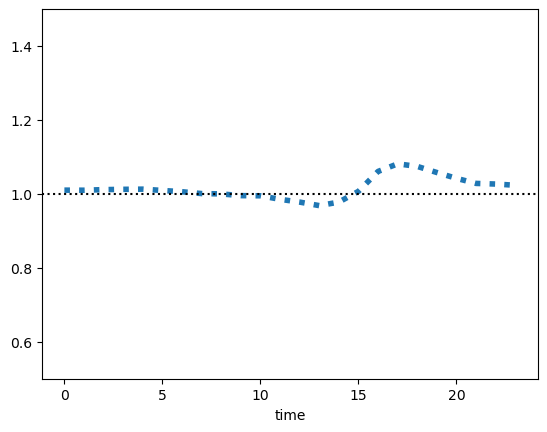

In [41]:
region_a="bunbury_near"
region_b_sb = df_gipps
region_b_no_sb = df_not_gipps

(region_b_sb[region_a].groupby(region_b_sb.index.hour).mean() /\
     region_b_no_sb[region_a].groupby(region_b_no_sb.index.hour).mean()).plot(label=bn + " SBF day",color=c,ls=l,lw=lw)

plt.gca().axhline(1,ls=":",color="k")
plt.ylim([0.5,1.5])